<a href="https://colab.research.google.com/github/FDB1228/Optimization_methods/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%967.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Необходимые функции

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon



# Определяем функции
def f1(x: np.ndarray) -> float:
    """Квадаратичная функция"""
    return (
        10 * x[0] ** 2
        - 4 * x[0] * x[1]
        + 7 * x[1] ** 2
        - 4 * np.sqrt(5) * (5 * x[0] - x[1])
        - 16
    )

def f2(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 1"""
    return (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2

def f3(x: np.ndarray) -> float:
    """Функция Розенброка alpha = 15"""
    return 15 * (x[0] ** 2 - x[1]) ** 2 + (x[0] - 1) ** 2



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def plot_regsimp(result, f, bounds=None):
    """
    Визуализация работы метода регулярного симплекса

    Параметры:
    result - результат функции regsimp
    f - целевая функция
    bounds - границы области визуализации [(xmin, xmax), (ymin, ymax)]
    levels - количество линий уровня
    title - заголовок графика
    """
    # Извлечение данных из результата
    xk_history, simplex_history = result[0:2]
    xk_history = np.array(xk_history)
    x_history = np.array([point[0] for point in xk_history])
    y_history = np.array([point[1] for point in xk_history])
    f_history = np.array([f(point) for point in xk_history])
    # Определение границ области
    if bounds is None:
        margin = 0.5
        xmin, xmax = xk_history[:,0].min()-margin, xk_history[:,0].max()+margin
        ymin, ymax = xk_history[:,1].min()-margin, xk_history[:,1].max()+margin
        bounds = [(xmin, xmax), (ymin, ymax)]

    # Создание сетки для линий уровня
    x = np.linspace(bounds[0][0], bounds[0][1], 200)
    y = np.linspace(bounds[1][0], bounds[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = np.array([[f([xi, yi]) for xi in x] for yi in y])

    # Настройка графика
    plt.figure(figsize=(10, 8))

    # Отображение траектории центра симплекса
    plt.plot(xk_history[:,0], xk_history[:,1], 'ko-', markersize=4, linewidth=1, zorder = 4)
    plt.scatter(xk_history[0,0], xk_history[0,1], c='green', s=100, label='Начальное приближение')
    plt.scatter(xk_history[-1,0], xk_history[-1,1], c='red', s=100, label='Точка минимума')

    # Отображение симплексов
    for i, simplex in enumerate(simplex_history):
        simplex = np.array(simplex)
        # Прозрачность уменьшается с каждой итерацией
        # alpha = 0.3 + 0.7*(i/len(simplex_history))
        poly = Polygon(simplex, closed=True, fill=False,
                       edgecolor='blue',
                      linestyle='--', linewidth=1)
        plt.gca().add_patch(poly)

    # Для каждой итерации рисуем линию уровня f(x) = f(x_k)
    for k, (xk, yk, fk) in enumerate(zip(x_history, y_history, f_history)):
        # Чтобы избежать дублирования, рисуем только уникальные уровни
        if k == 0 or not np.isclose(fk, f_history[k-1], atol=1e-6):
          if k <= 10 or k % 20 == 0:
            cs = plt.contour(X, Y, Z, levels=[fk], colors='red', alpha=0.5)
    cs = plt.contour(X, Y, Z, levels=[f_history[-1]], colors='red', alpha=0.5)

    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    if bounds:
        plt.xlim(bounds[0])
        plt.ylim(bounds[1])
    plt.show()

def plot_irregsimp(result, f, bounds=None):
    """
    Полная визуализация всех симплексов метода Нелдера-Мида

    Параметры:
    result - результат функции irregsimp
    f - целевая функция
    bounds - границы области визуализации [(xmin, xmax), (ymin, ymax)]
    levels - количество линий уровня
    title - заголовок графика
    """
    # Извлечение данных
    xk_history, simplex_history = result[0:2]
    xk_history = np.array(xk_history)
    n_simplices = len(simplex_history)
    x_history = np.array([point[0] for point in xk_history])
    y_history = np.array([point[1] for point in xk_history])
    f_history = np.array([f(point) for point in xk_history])


    # Определение границ
    if bounds is None:
        all_points = np.array([p for simplex in simplex_history for p in simplex])
        margin = 0.5
        xmin, ymin = all_points.min(axis=0) - margin
        xmax, ymax = all_points.max(axis=0) + margin
        bounds = [(xmin, xmax), (ymin, ymax)]

    # Создание сетки
    x = np.linspace(bounds[0][0], bounds[0][1], 200)
    y = np.linspace(bounds[1][0], bounds[1][1], 200)
    X, Y = np.meshgrid(x, y)
    Z = np.array([[f([xi, yi]) for xi in x] for yi in y])

    # Настройка графика
    plt.figure(figsize=(12, 9))


    # Траектория центра
    plt.plot(xk_history[:,0], xk_history[:,1], 'ko-', markersize=4, zorder = 5)
    plt.scatter(xk_history[0,0], xk_history[0,1], c='green', s=100, label='Начальное приближение', zorder=5)
    plt.scatter(xk_history[-1,0], xk_history[-1,1], c='red', s=100, label='Точка минимума', zorder=5)

    # Отображение всех симплексов с разной прозрачностью
    for i, simplex in enumerate(simplex_history):
        simplex = np.array(simplex)

        # Прозрачность зависит от номера итерации
        # alpha = 0.1 + 0.9 * (i / n_simplices)  # Поздние итерации более заметны

        # Основной полигон
        poly = Polygon(simplex, closed=True, fill = False,
                       edgecolor='blue',
                      linestyle='--', linewidth=1)
        plt.gca().add_patch(poly)



    # Для каждой итерации рисуем линию уровня f(x) = f(x_k)
    for k, (xk, yk, fk) in enumerate(zip(x_history, y_history, f_history)):
        # Чтобы избежать дублирования, рисуем только уникальные уровни
        if k == 0 or not np.isclose(fk, f_history[k-1], atol=1e-6):
          if k <= 10 or k % 40 == 0:
            cs = plt.contour(X, Y, Z, levels=[fk], colors='red', alpha=0.5)
    cs = plt.contour(X, Y, Z, levels=[f_history[-1]], colors='red', alpha=0.5)


    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

In [ ]:
# @title Реализация регулярного симплекса
def regsimp(init: list, f, eps, df=None, max_iters=50000):
    def simplex(x: list, l: float = 1) -> list:
        """Создает правильный (равносторонний) симплекс в 2D"""
        return [
            x.copy(),
            [
                x[0] + l * (np.sqrt(3) - 1) / (2 * np.sqrt(2)),
                x[1] + l * (np.sqrt(3) + 1) / (2 * np.sqrt(2))
            ],
            [
                x[0] + l * (np.sqrt(3) + 1) / (2 * np.sqrt(2)),
                x[1] + l * (np.sqrt(3) - 1) / (2 * np.sqrt(2))
            ]
        ]

    res = [0, [[init[0], init[1]]], []]
    fiter = 0
    xk_history = [[init[0], init[1]]]
    simplex_history =[]
    l = 1.0
    xk = [init[0], init[1]]
    sk = simplex(xk, l)
    simplex_history.append([point.copy() for point in sk])

    fsk = [f(point) for point in sk]
    fiter += 3

    itr = 0

    while itr < max_iters:
        itr += 1

        sorted_indices = sorted(range(3), key=lambda i: -fsk[i])
        ind_max = sorted_indices[0]
        ind_second = sorted_indices[1]
        ind_min = sorted_indices[2]

        xc = [0.0, 0.0]
        for i in range(3):
            if i != ind_max:
                xc[0] += sk[i][0]
                xc[1] += sk[i][1]
        xc[0] /= 2
        xc[1] /= 2
        xk_history.append(xc.copy())

        std_dev = np.sqrt(sum((fval - sum(fsk)/3)**2 for fval in fsk) / 3)
        if std_dev < eps:
            break

        xr = [
            2 * xc[0] - sk[ind_max][0],
            2 * xc[1] - sk[ind_max][1]
        ]
        fr = f(xr)
        fiter += 1

        reflection_success = False

        if fr < fsk[ind_max]:
            sk[ind_max] = xr
            fsk[ind_max] = fr
            reflection_success = True
        else:

            xc_second = [0.0, 0.0]
            for i in range(3):
                if i != ind_second:
                    xc_second[0] += sk[i][0]
                    xc_second[1] += sk[i][1]
            xc_second[0] /= 2
            xc_second[1] /= 2

            xr_second = [
                2 * xc_second[0] - sk[ind_second][0],
                2 * xc_second[1] - sk[ind_second][1]
            ]
            fr_second = f(xr_second)
            fiter += 1

            if fr_second < fsk[ind_second]:

                sk[ind_second] = xr_second
                fsk[ind_second] = fr_second
                reflection_success = True

        if not reflection_success:

            for i in range(3):
                if i != ind_min:
                    sk[i] = [
                        sk[ind_min][0] + 0.5 * (sk[i][0] - sk[ind_min][0]),
                        sk[ind_min][1] + 0.5 * (sk[i][1] - sk[ind_min][1])
                    ]
                    fsk[i] = f(sk[i])
                    fiter += 1

        simplex_history.append([point.copy() for point in sk])


    info = [xk_history, simplex_history, init,eps, itr,fiter,xk_history[-1],f(xk_history[-1])]
    return info

In [ ]:
# @title Реализация нерегулярного сиплекса
def irregsimp(init: list, f, eps: float = 10**(-8), df = None, max_iters = 50000):
    def simplex(x: list, l: float = 1) -> list:
        return [
            x.copy(),
            [
                x[0] + l * (np.sqrt(3) - 1) / (2 * np.sqrt(2)),
                x[1] + l * (np.sqrt(3) + 1) / (2 * np.sqrt(2))
            ],
            [
                x[0] + l * (np.sqrt(3) + 1) / (2 * np.sqrt(2)),
                x[1] + l * (np.sqrt(3) - 1) / (2 * np.sqrt(2))
            ]
        ]

    alpha = 1.0
    beta = 2.0
    gamma = 0.5
    delta = 0.5

    xk_history = [[init[0], init[1]]]
    simplex_history =[]
    fiter = 0


    sk = simplex(init, 1.0)
    simplex_history.append([point.copy() for point in sk])


    fsk = [f(point) for point in sk]
    fiter += 3

    itr = 0

    while itr < max_iters:
        itr += 1


        sorted_indices = sorted(range(3), key=lambda i: fsk[i])
        ind_min = sorted_indices[0]
        ind_mid = sorted_indices[1]
        ind_max = sorted_indices[2]


        xc = [0.0, 0.0]
        for i in range(3):
            if i != ind_max:
                xc[0] += sk[i][0]
                xc[1] += sk[i][1]
        xc[0] /= 2
        xc[1] /= 2
        xk_history.append(xc.copy())


        std_dev = np.sqrt(sum((fval - sum(fsk)/3)**2 for fval in fsk) / 3)
        if std_dev < eps:
            break


        xr = [
            xc[0] + alpha * (xc[0] - sk[ind_max][0]),
            xc[1] + alpha * (xc[1] - sk[ind_max][1])
        ]
        fr = f(xr)
        fiter += 1

        if fr < fsk[ind_min]:

            xe = [
                xc[0] + beta * (xr[0] - xc[0]),
                xc[1] + beta * (xr[1] - xc[1])
            ]
            fe = f(xe)
            fiter += 1

            if fe < fr:
                sk[ind_max] = xe
                fsk[ind_max] = fe
            else:
                sk[ind_max] = xr
                fsk[ind_max] = fr
        elif fr < fsk[ind_mid]:

            sk[ind_max] = xr
            fsk[ind_max] = fr
        else:
            if fr < fsk[ind_max]:

                xc1 = [
                    xc[0] + gamma * (xr[0] - xc[0]),
                    xc[1] + gamma * (xr[1] - xc[1])
                ]
                fc1 = f(xc1)
                fiter += 1

                if fc1 < fr:
                    sk[ind_max] = xc1
                    fsk[ind_max] = fc1
                else:
                    for i in range(3):
                        if i != ind_min:
                            sk[i] = [
                                sk[ind_min][0] + delta * (sk[i][0] - sk[ind_min][0]),
                                sk[ind_min][1] + delta * (sk[i][1] - sk[ind_min][1])
                            ]
                            fsk[i] = f(sk[i])
                            fiter += 1
            else:

                xc2 = [
                    xc[0] + gamma * (sk[ind_max][0] - xc[0]),
                    xc[1] + gamma * (sk[ind_max][1] - xc[1])
                ]
                fc2 = f(xc2)
                fiter += 1

                if fc2 < fsk[ind_max]:
                    sk[ind_max] = xc2
                    fsk[ind_max] = fc2
                else:
                    for i in range(3):
                        if i != ind_min:
                            sk[i] = [
                                sk[ind_min][0] + delta * (sk[i][0] - sk[ind_min][0]),
                                sk[ind_min][1] + delta * (sk[i][1] - sk[ind_min][1])
                            ]
                            fsk[i] = f(sk[i])
                            fiter += 1

        simplex_history.append([point.copy() for point in sk])


    info = [xk_history, simplex_history, init,eps,itr,fiter,xk_history[-1],f(xk_history[-1])]
    return info

In [ ]:
# @title Регулярный симплекс
x1 = [5.0, -2.0]
eps1 = 1e-2

x2 = [-5.0, 10.0]
eps2 = 1e-5

reg_quad_1 = regsimp(x1, f1, eps1)
reg_quad_2 = regsimp(x1, f1, eps2)
reg_quad_3 = regsimp(x2, f1, eps1)
reg_quad_4 = regsimp(x2, f1, eps2)

reg_r1_1 = regsimp(x1, f2, eps1)
reg_r1_2 = regsimp(x1, f2, eps2)
reg_r1_3 = regsimp(x2, f2, eps1)
reg_r1_4 = regsimp(x2, f2, eps2)

reg_r15_1 = regsimp(x1, f3, eps1)
reg_r15_2 = regsimp(x1, f3, eps2)
reg_r15_3 = regsimp(x2, f3, eps1)
reg_r15_4 = regsimp(x2, f3, eps2)


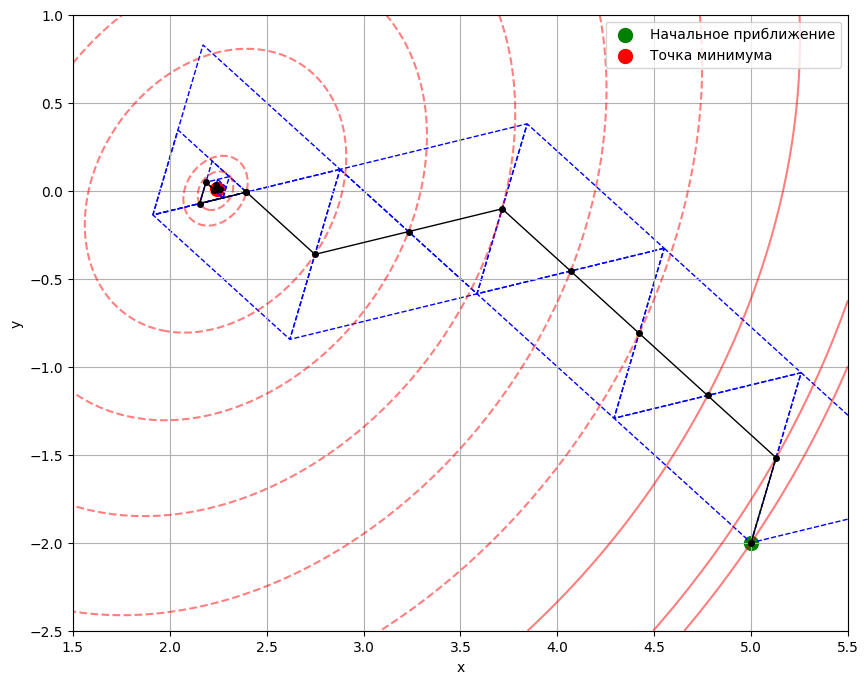

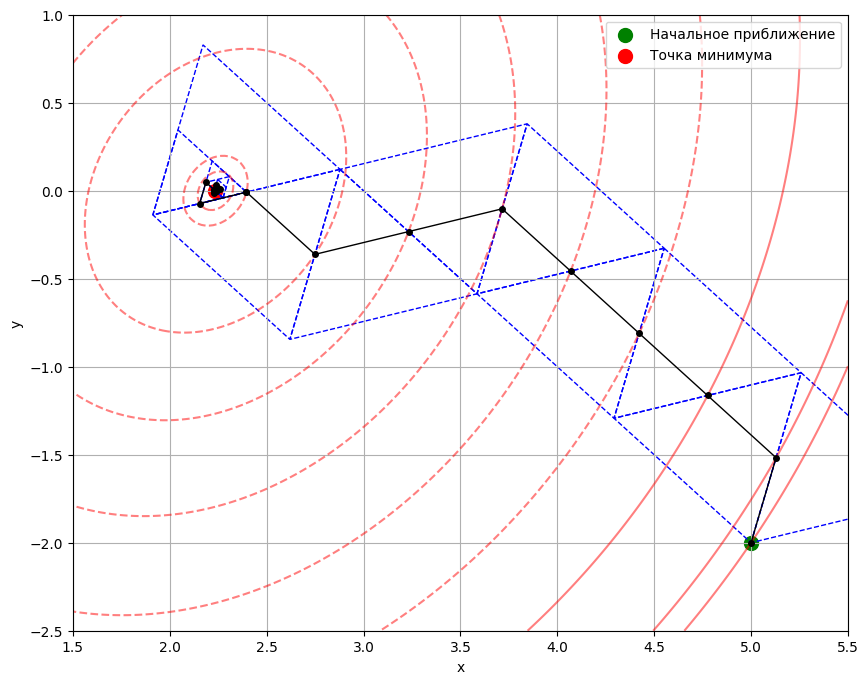

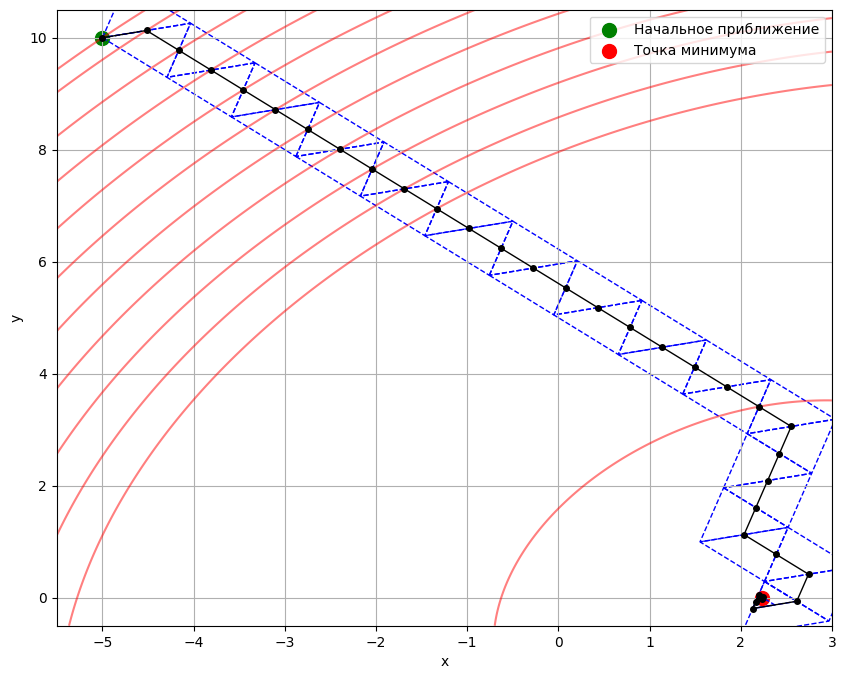

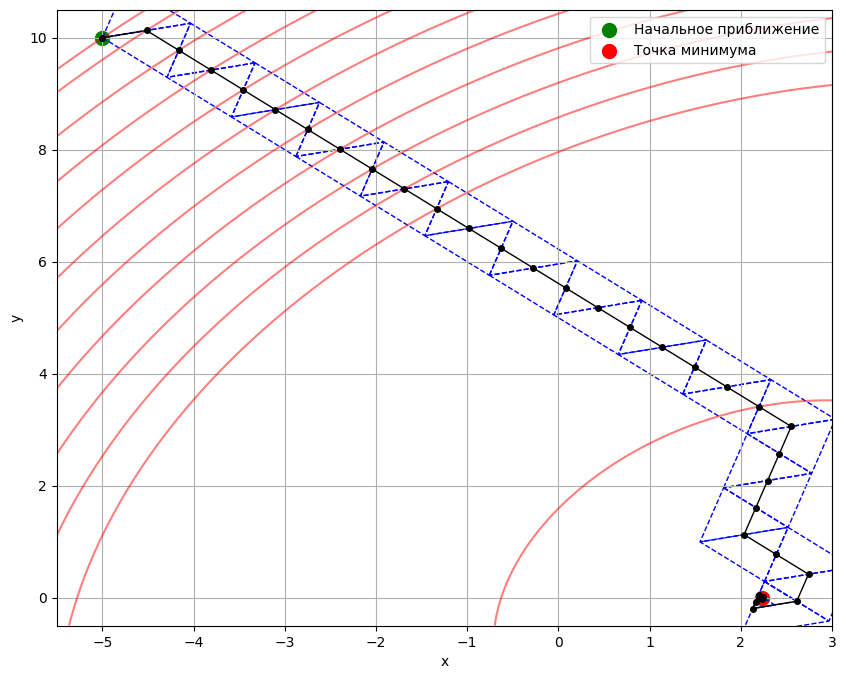

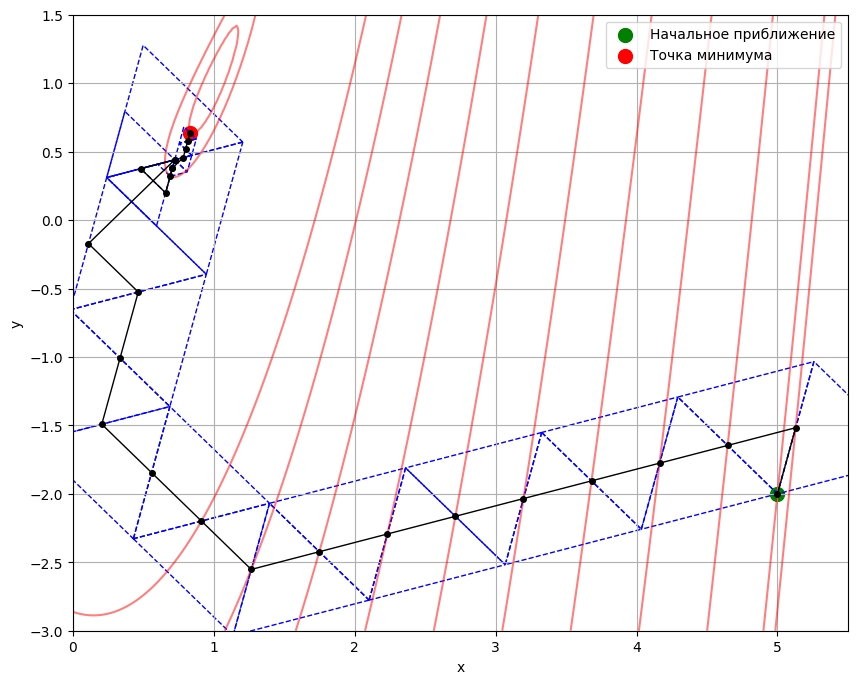

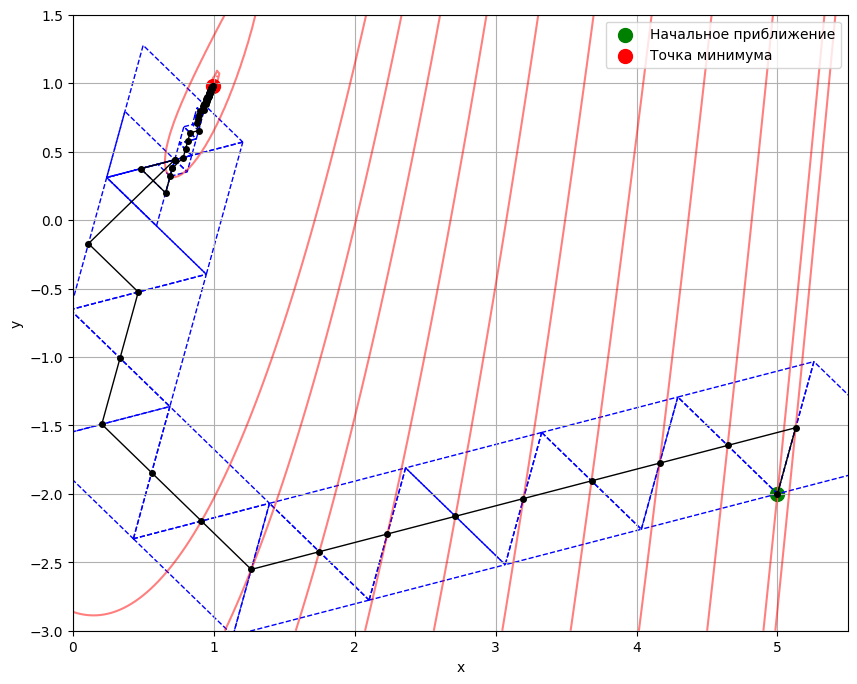

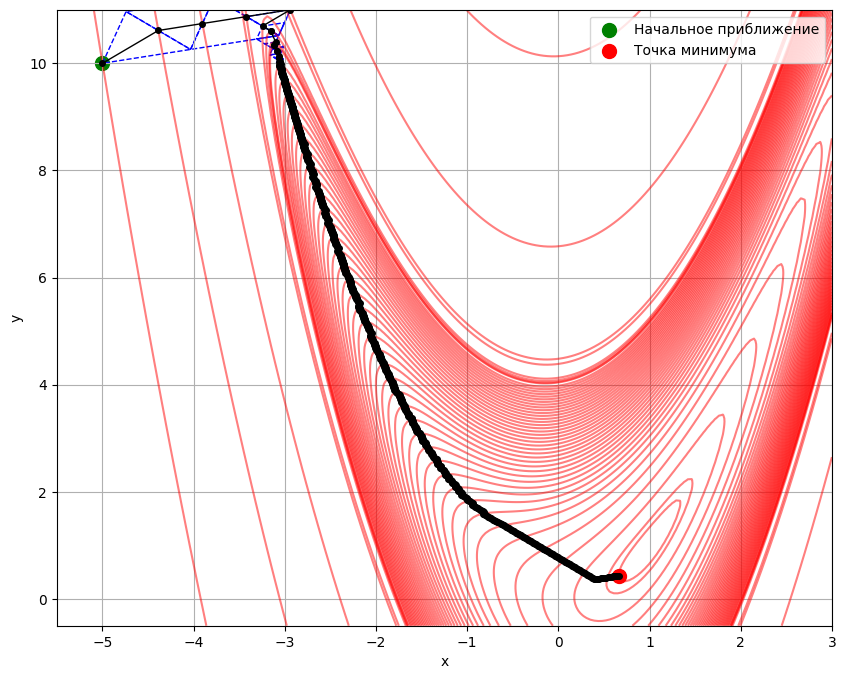

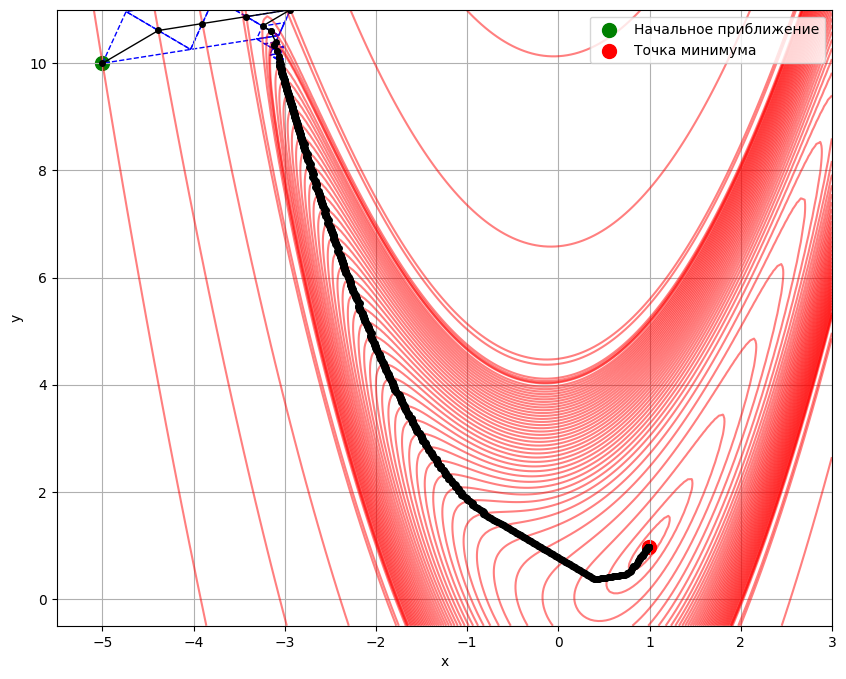

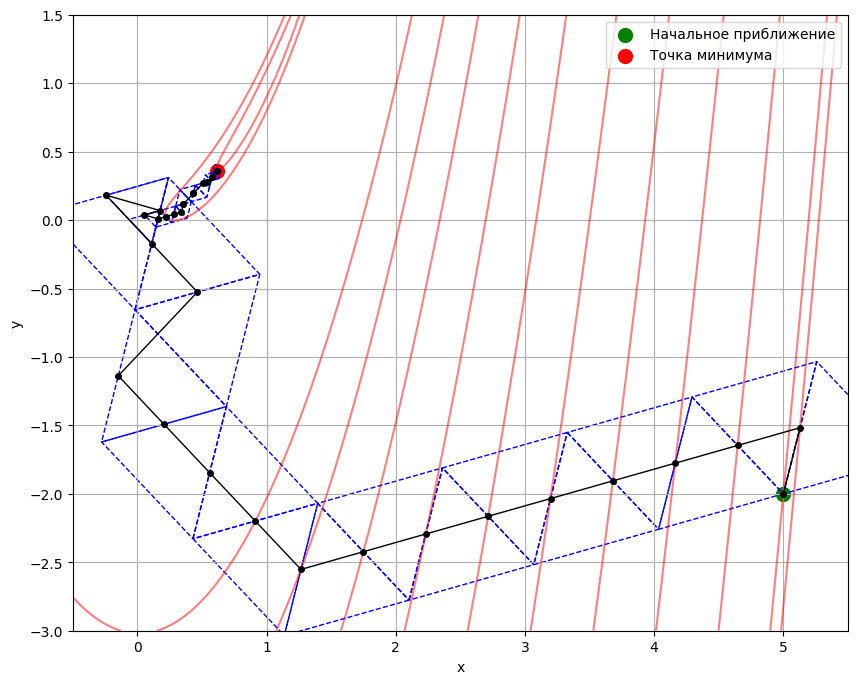

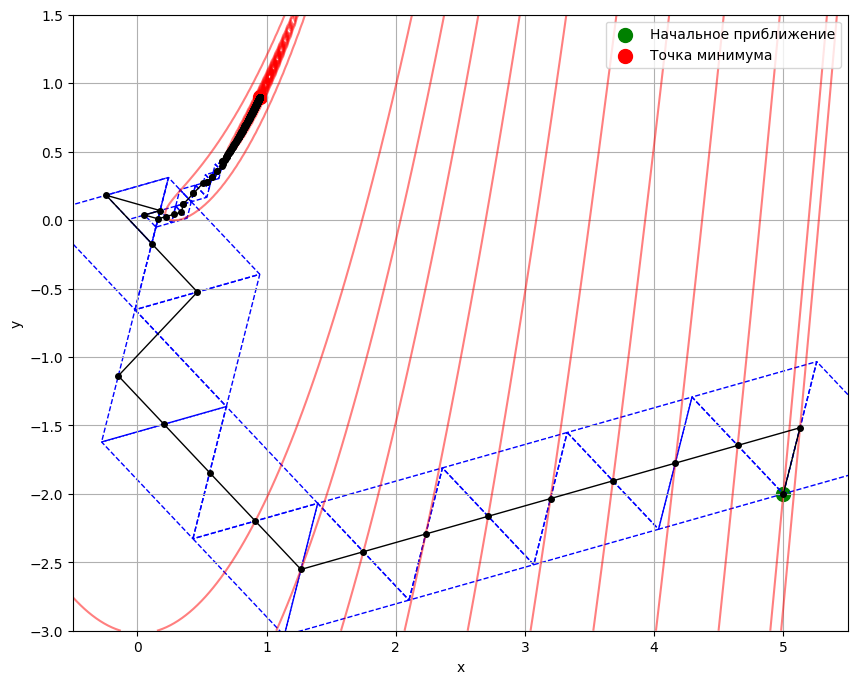

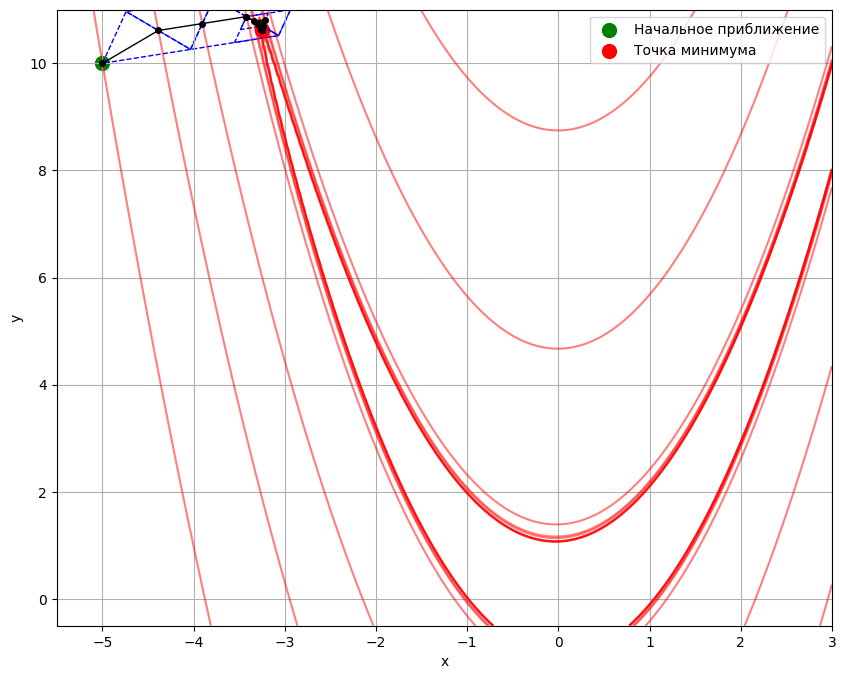

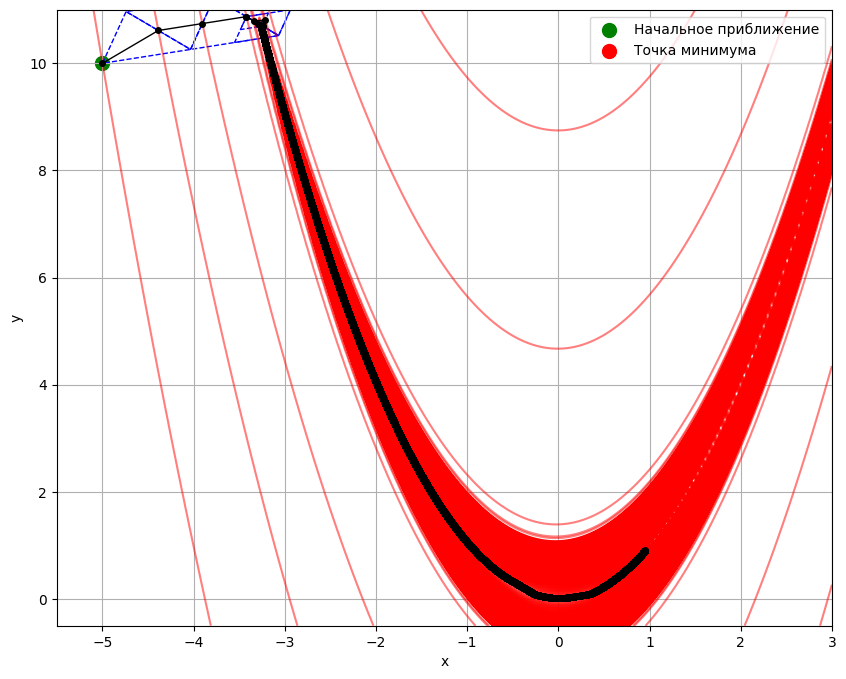

In [ ]:
# @title Визуализация рег. симплекса
b1 = [[1.5,5.5],[-2.5, 1]]
b2 = [[-5.5, 3],[-0.5, 10.5]]

plot_regsimp(reg_quad_1, f1, b1)
plot_regsimp(reg_quad_2, f1, b1)
plot_regsimp(reg_quad_3, f1, b2)
plot_regsimp(reg_quad_4, f1, b2)

b1 = [[0,5.5],[-3, 1.5]]
b2 = [[-5.5, 3],[-0.5, 11]]

plot_regsimp(reg_r1_1, f2, b1)
plot_regsimp(reg_r1_2, f2, b1)
plot_regsimp(reg_r1_3, f2, b2)
plot_regsimp(reg_r1_4, f2, b2)

b1 = [[-0.5,5.5],[-3, 1.5]]
b2 = [[-5.5, 3],[-0.5, 11]]

plot_regsimp(reg_r15_1, f3, b1)
plot_regsimp(reg_r15_2, f3, b1)
plot_regsimp(reg_r15_3, f3, b2)
plot_regsimp(reg_r15_4, f3, b2)

In [ ]:
# @title Нерегулярный симплекс
x1 = [5.0, -2.0]
eps1 = 1e-2

x2 = [-5.0, 10.0]
eps2 = 1e-5

irreg_quad_1 = irregsimp(x1, f1, eps1)
irreg_quad_2 = irregsimp(x1, f1, eps2)
irreg_quad_3 = irregsimp(x2, f1, eps1)
irreg_quad_4 = irregsimp(x2, f1, eps2)

irreg_r1_1 = irregsimp(x1, f2, eps1)
irreg_r1_2 = irregsimp(x1, f2, eps2)
irreg_r1_3 = irregsimp(x2, f2, eps1)
irreg_r1_4 = irregsimp(x2, f2, eps2)

irreg_r15_1 = irregsimp(x1, f3, eps1)
irreg_r15_2 = irregsimp(x1, f3, eps2)
irreg_r15_3 = irregsimp(x2, f3, eps1)
irreg_r15_4 = irregsimp(x2, f3, eps2)

In [ ]:
# @title Визуализация нерег. симплекса

b1 = [[1,6],[-2.5, 1]]
b2 = [[-5.5, 4],[-2.5, 11]]

plot_irregsimp(irreg_quad_1, f1, b1)
plot_irregsimp(irreg_quad_2, f1, b1)
plot_irregsimp(irreg_quad_3, f1, b2)
plot_irregsimp(irreg_quad_4, f1, b2)

b1 = [[-1,6],[-3.5, 1.5]]
b2 = [[-5.5, 3],[-2, 12]]

plot_irregsimp(irreg_r1_1, f2, b1)
plot_irregsimp(irreg_r1_2, f2, b1)
plot_irregsimp(irreg_r1_3, f2, b2)
plot_irregsimp(irreg_r1_4, f2, b2)

b1 = [[-2,6],[-3.5, 1.5]]
b2 = [[-5.5, 2],[-0.5, 12]]

plot_irregsimp(irreg_r15_1, f3, b1)
plot_irregsimp(irreg_r15_2, f3, b1)
plot_irregsimp(irreg_r15_3, f3, b2)
plot_irregsimp(irreg_r15_4, f3, b2)

In [ ]:
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброк (alpha = 1)","Розенброк (alpha = 1)","Розенброк (alpha = 1)","Розенброк (alpha = 1)","Розенброк (alpha = 15)","Розенброк (alpha = 15)","Розенброк (alpha = 15)","Розенброк (alpha = 15)"]
data = [reg_quad_1[2:],reg_quad_2[2:], reg_quad_3[2:], reg_quad_4[2:], reg_r1_1[2:],reg_r1_2[2:], reg_r1_3[2:], reg_r1_4[2:], reg_r15_1[2:],reg_r15_2[2:],reg_r15_3[2:],reg_r15_4[2:]]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+------------------------+-------------------------+-------+-------------------+-------------------+-----------------------------------------------------------------------+------------------------+
|                        | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии | Найденная точка минимума                                              |   Найденное знач. ф-ии |
+========================+=========================+=======+===================+===================+=======================================================================+========================+
| Квадратичная           | [5.0, -2.0]             | 0.01  |                16 |                33 | [np.float64(2.2458744322212967), np.float64(0.007796661774453026)]    |          -65.9989      |
+------------------------+-------------------------+-------+-------------------+-------------------+-----------------------------------------------------------------------+------------------------+
| Квадрати

In [ ]:
import pandas as pd
from tabulate import tabulate
column_headers = ["Начальное приближение", "ε", "Кол-во итераций", "Кол-вы выч ф-ии", "Найденная точка минимума", "Найденное знач. ф-ии"]
row_headers =["Квадратичная","Квадратичная","Квадратичная","Квадратичная","Розенброк (alpha = 1)","Розенброк (alpha = 1)","Розенброк (alpha = 1)","Розенброк (alpha = 1)","Розенброк (alpha = 15)","Розенброк (alpha = 15)","Розенброк (alpha = 15)","Розенброк (alpha = 15)"]
data = [irreg_quad_1[2:],irreg_quad_2[2:], irreg_quad_3[2:], irreg_quad_4[2:], irreg_r1_1[2:],irreg_r1_2[2:], irreg_r1_3[2:], irreg_r1_4[2:], irreg_r15_1[2:],irreg_r15_2[2:],irreg_r15_3[2:],irreg_r15_4[2:]]
df = pd.DataFrame(data, index=row_headers, columns=column_headers)

print(tabulate(df, headers='keys', tablefmt='grid'))

+------------------------+-------------------------+-------+-------------------+-------------------+----------------------------------------------------------------------+------------------------+
|                        | Начальное приближение   |     ε |   Кол-во итераций |   Кол-вы выч ф-ии | Найденная точка минимума                                             |   Найденное знач. ф-ии |
+========================+=========================+=======+===================+===================+======================================================================+========================+
| Квадратичная           | [5.0, -2.0]             | 0.01  |                15 |                30 | [np.float64(2.199908438943024), np.float64(-0.00552541722037388)]    |          -65.9875      |
+------------------------+-------------------------+-------+-------------------+-------------------+----------------------------------------------------------------------+------------------------+
| Квадратичная 